# Binary mortgage approval classification

در این نوت‌بوک فقط روی ساخت دیتاست‌های متوازن از فایل اصلی HMDA کار می‌کنیم.
ابتدا داده را می‌خوانیم، بعد تعداد کلاس‌ها را بررسی می‌کنیم، بعد دو نسخه‌ی متوازن می‌سازیم:
یکی با under-sampling و یکی با رسیدن هر دو کلاس به 200 هزار نمونه.

## 1) بارگذاری داده

در این سلول فایل CSV اصلی را می‌خوانیم و چند سطر اول را برای اطمینان از درست بودن بارگذاری نمایش می‌دهیم.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split
DATA_FILE = Path("hmda_classification_stratified_500k.csv")
TARGET_COL = "loan_approved"
RANDOM_STATE = 42
df = pd.read_csv(DATA_FILE, low_memory=False)
df.head()

,respondent_id,agency_name,loan_type_name,property_type_name,loan_purpose_name,owner_occupancy_name,loan_amount_000s,preapproval_name,msamd_name,state_name,...,co_applicant_sex_name,applicant_income_000s,lien_status_name,population,minority_population,hud_median_family_income,tract_to_msamd_income,number_of_owner_occupied_units,number_of_1_to_4_family_units,loan_approved
0,0000480228,Consumer Financial Protection Bureau,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,448,Not applicable,Camden - NJ,New Jersey,...,Female,161,Secured by a first lien,5422,8.230000,91500,169.550003,1425,1602,1
1,0000914648,Federal Reserve System,Conventional,One-to-four family dwelling (other than manufa...,Home improvement,Not owner-occupied as a principal dwelling,77,Not applicable,Tuscaloosa - AL,Alabama,...,No co-applicant,113,Secured by a first lien,2996,56.070000,58800,75.529999,348,723,1
2,0000675332,Consumer Financial Protection Bureau,Conventional,One-to-four family dwelling (other than manufa...,Home improvement,Owner-occupied as a principal dwelling,31,Not applicable,Florence - SC,South Carolina,...,No co-applicant,176,Not secured by a lien,5998,10.940000,53900,146.149994,1814,2665,1
3,0000058088,Federal Deposit Insurance Corporation,Conventional,One-to-four family dwelling (other than manufa...,Refinancing,Not owner-occupied as a principal dwelling,66,Not applicable,"Daphne, Fairhope, Foley - AL",Alabama,...,Female,147,Secured by a first lien,5321,17.100000,61500,95.389999,1219,1985,1
4,7197000003,Department of Housing and Urban Development,Conventional,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,184,Not applicable,"San Diego, Carlsbad - CA",California,...,No co-applicant,80,Secured by a first lien,9349,65.370003,79300,85.389999,2004,2948,1


## 2) بررسی تعداد کلاس‌ها

در این بخش تعداد نمونه‌های هر کلاس را می‌بینیم تا مشخص شود کلاس اکثریت و اقلیت کدام‌اند.

In [3]:
class_counts = df[TARGET_COL].value_counts().sort_index()
class_counts

loan_approved
0     98774
1    401226
Name: count, dtype: int64

## 3) ساخت دیتاست under-sampled

در این سلول کلاس اکثریت را تا اندازه‌ی کلاس اقلیت پایین می‌آوریم تا هر دو کلاس به یک اندازه شوند.
این روش حجم داده را کم می‌کند ولی تعادل کامل می‌دهد.

In [4]:
minority_label = class_counts.idxmin()
majority_label = class_counts.idxmax()
target_size = int(class_counts.min())

minority_df = df[df[TARGET_COL] == minority_label]
majority_df = df[df[TARGET_COL] == majority_label].sample(
    n=target_size,
    random_state=RANDOM_STATE,
    replace=False,
)

under_sampled_df = (
    pd.concat([minority_df, majority_df], axis=0)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

under_sampled_df[TARGET_COL].value_counts().sort_index()
under_sampled_df.to_csv("under_sampled_df.csv", sep=",", index=False)

## 4) ساخت دیتاست 200k/200k

در این بخش کلاس اقلیت را با نمونه‌گیری مجدد به 200 هزار ردیف می‌رسانیم و کلاس اکثریت را هم به 200 هزار کاهش می‌دهیم.
این روش هم داده‌ی اقلیت را بیشتر می‌کند و هم بخش مهمی از داده‌ی اکثریت را نگه می‌دارد.

In [5]:
target_200k = 200_000

minority_200k_df = df[df[TARGET_COL] == minority_label].sample(
    n=target_200k,
    random_state=RANDOM_STATE,
    replace=True,
)
majority_200k_df = df[df[TARGET_COL] == majority_label].sample(
    n=target_200k,
    random_state=RANDOM_STATE,
    replace=False,
)

balanced_200k_df = (
    pd.concat([minority_200k_df, majority_200k_df], axis=0)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

balanced_200k_df[TARGET_COL].value_counts().sort_index()
balanced_200k_df.to_csv("balanced_200k_df.csv", sep=",", index=False)

## 5) ذخیره‌ی خروجی‌ها

در این سلول هر دو دیتاست متوازن را به فایل CSV جداگانه ذخیره می‌کنیم تا بعداً برای آموزش مدل از آن‌ها استفاده شود.

In [6]:
under_sampled_df.to_csv("hmda_under_sampled_balanced.csv", index=False)
balanced_200k_df.to_csv("hmda_balanced_200k_each.csv", index=False)

print("Saved: hmda_under_sampled_balanced.csv")
print("Saved: hmda_balanced_200k_each.csv")

Saved: hmda_under_sampled_balanced.csv
Saved: hmda_balanced_200k_each.csv


## 6) نمایش توزیع ویژگی‌ها بر اساس کلاس هدف

در این بخش توزیع هر ویژگی را برای دو کلاس `loan_approved=0` و `loan_approved=1` جداگانه رسم می‌کنیم.
برای ویژگی‌های عددی از هیستوگرام و برای ویژگی‌های دسته‌ای از count plot استفاده می‌شود.

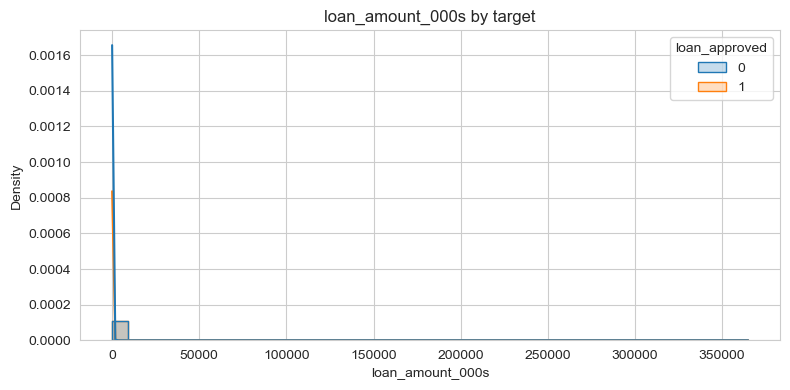

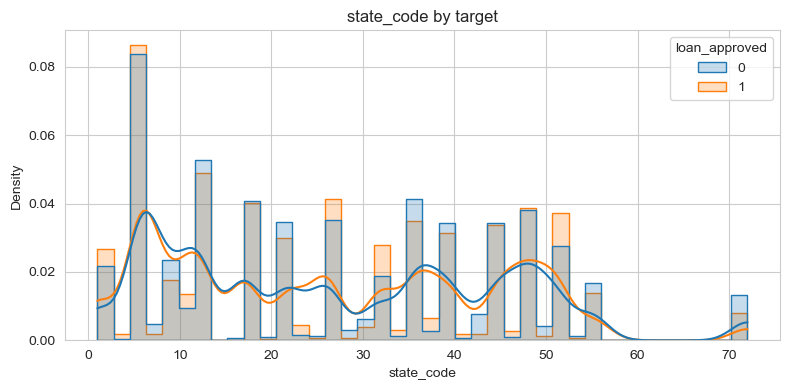

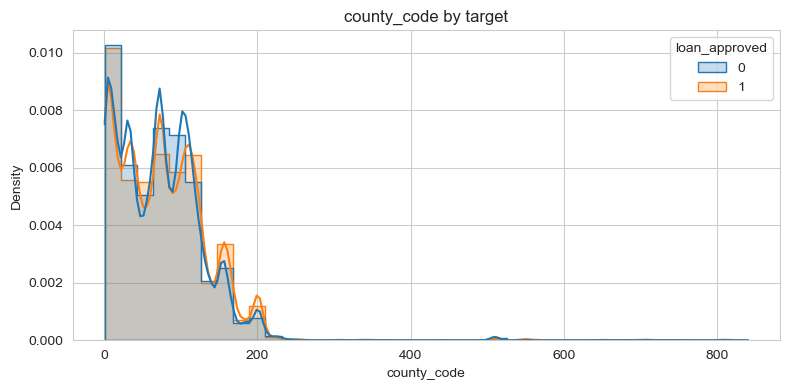

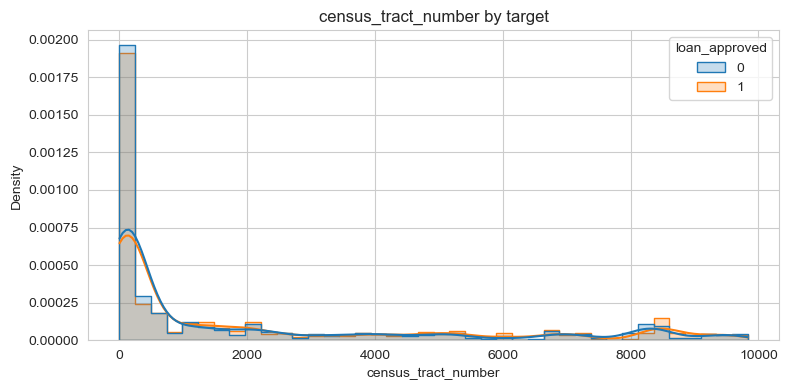

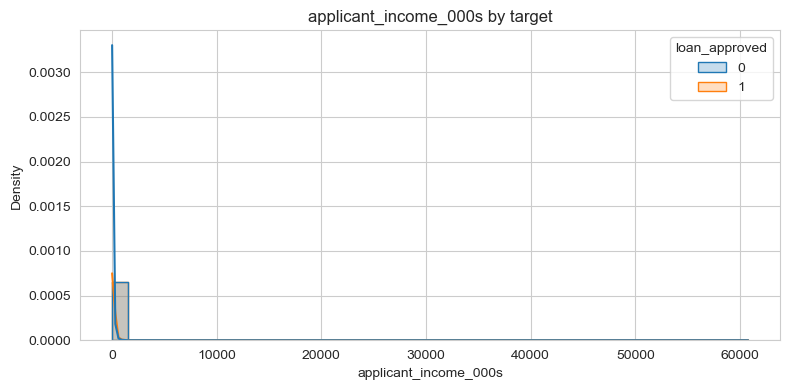

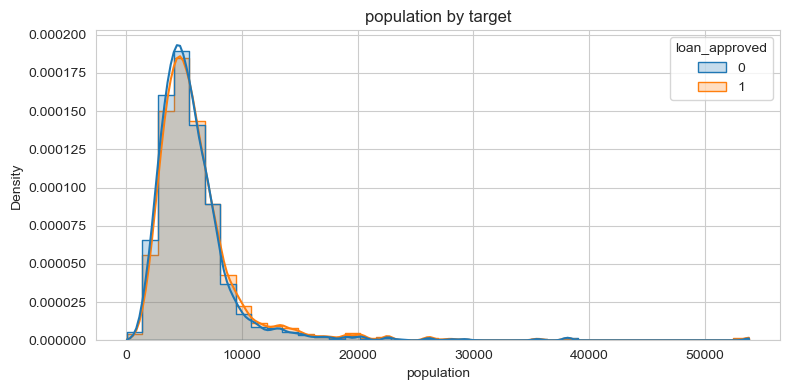

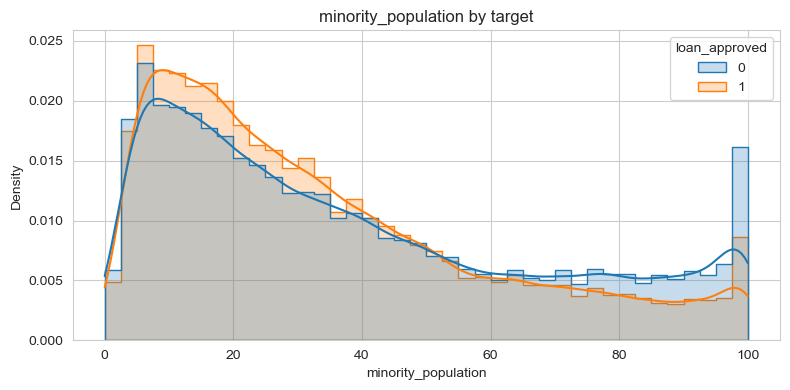

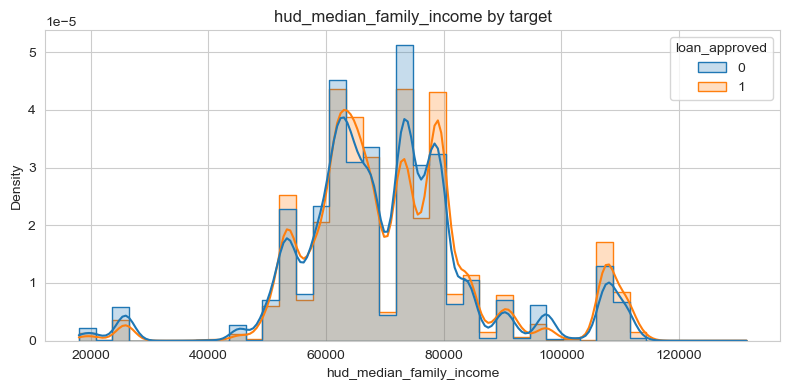

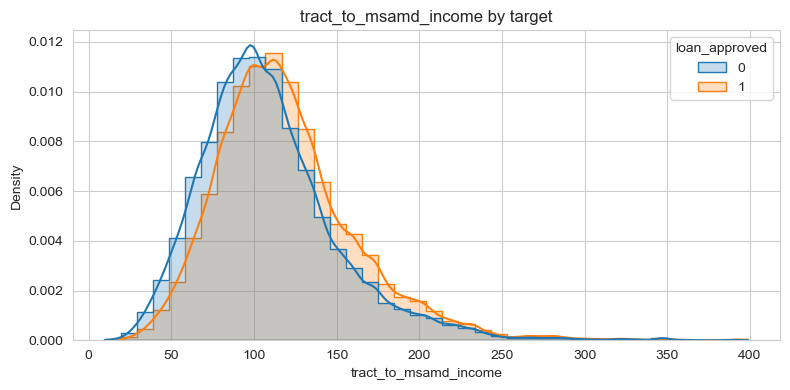

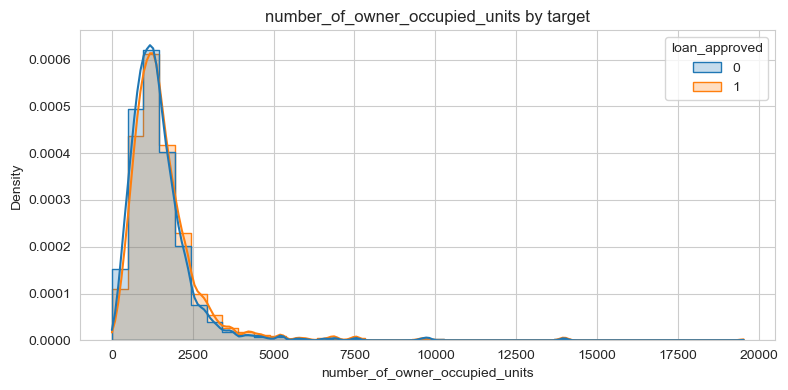

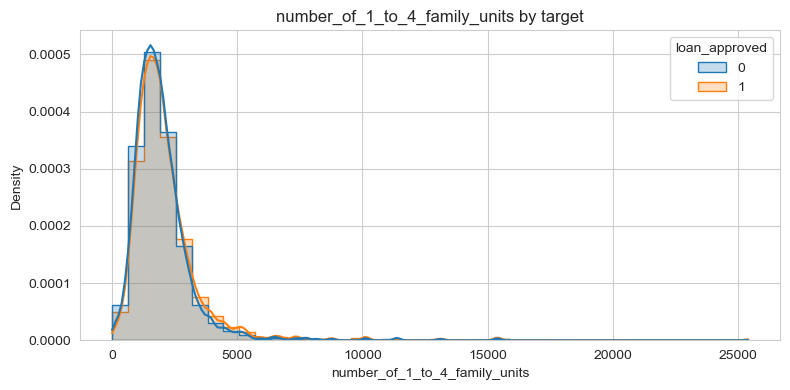

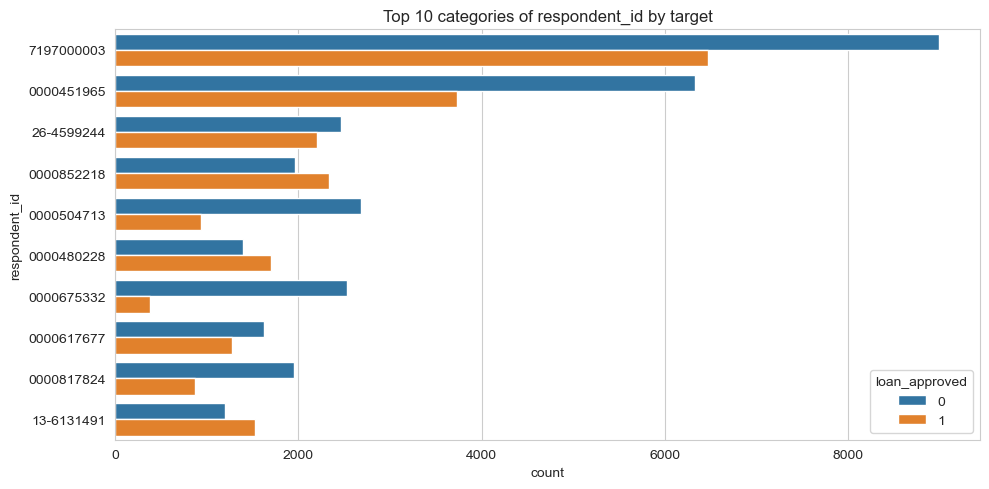

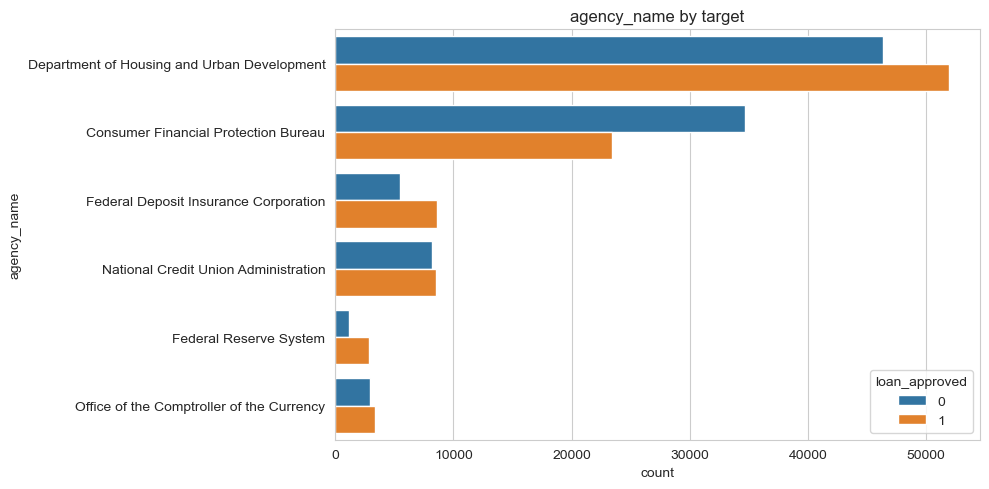

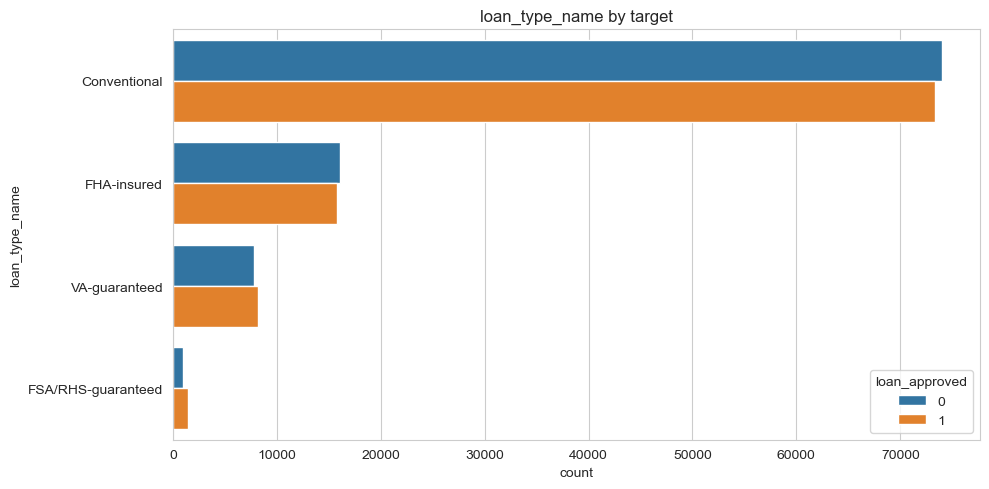

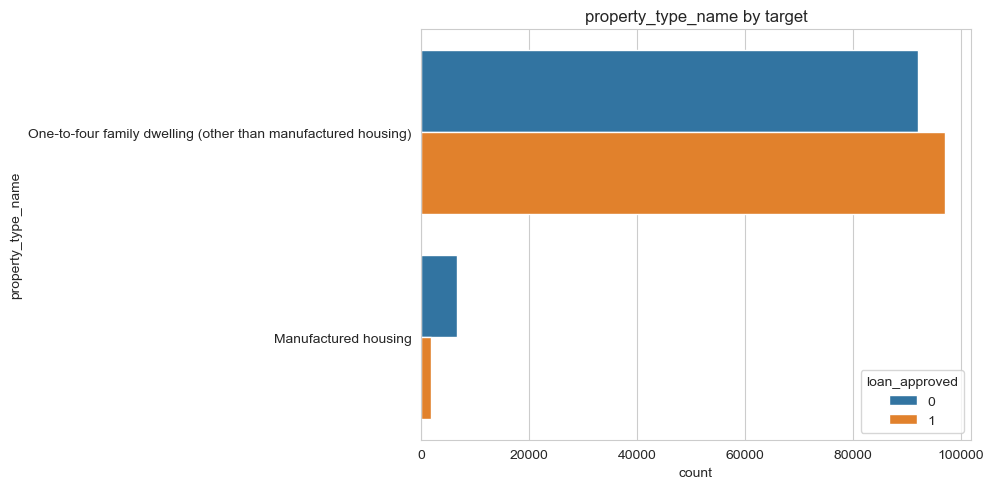

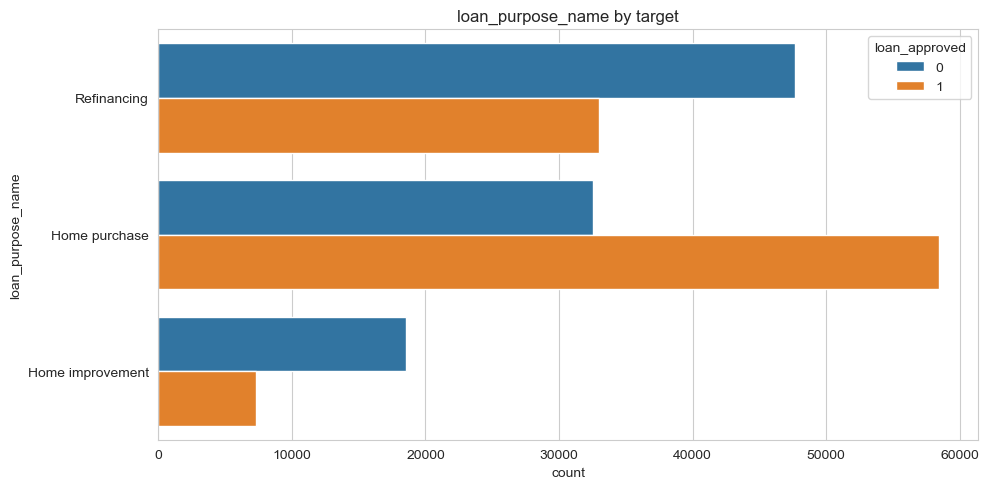

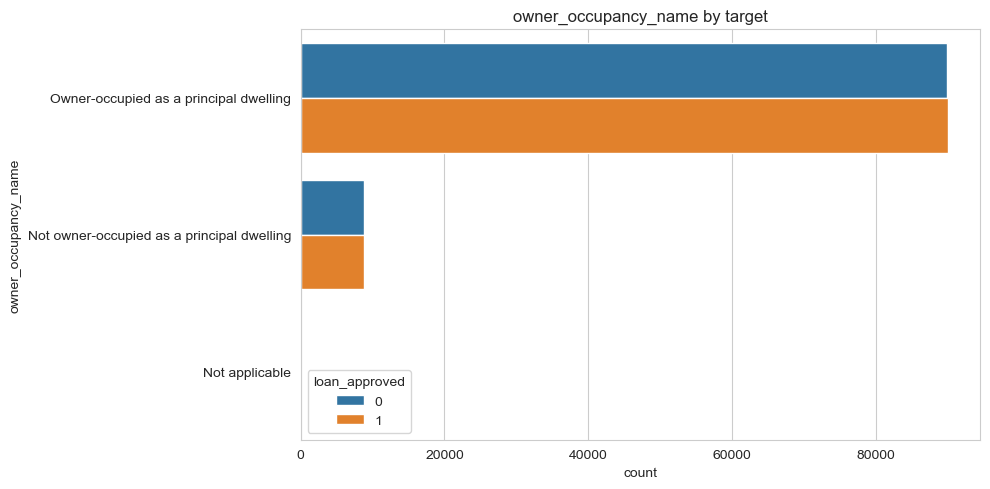

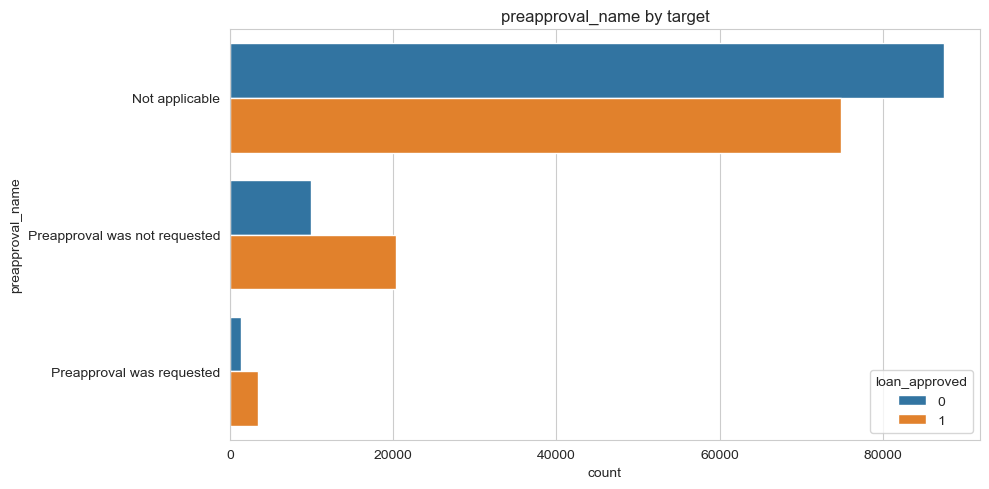

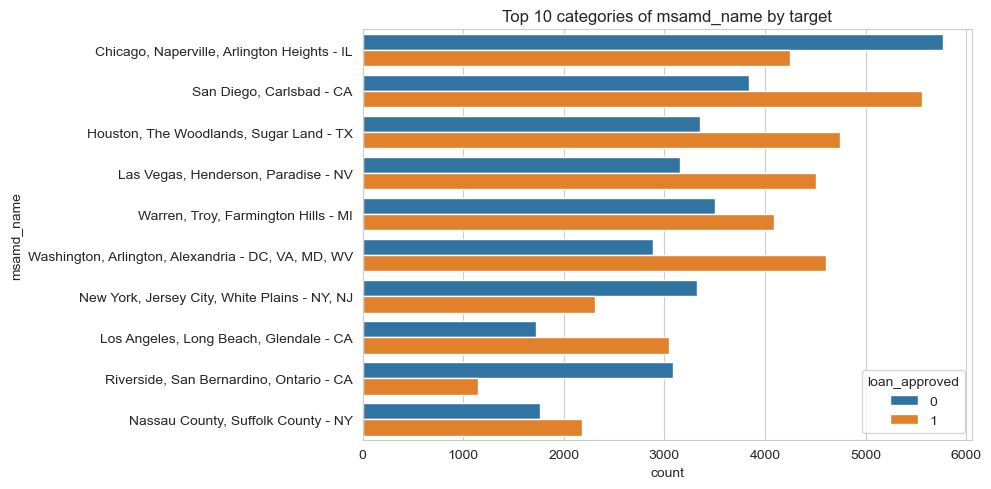

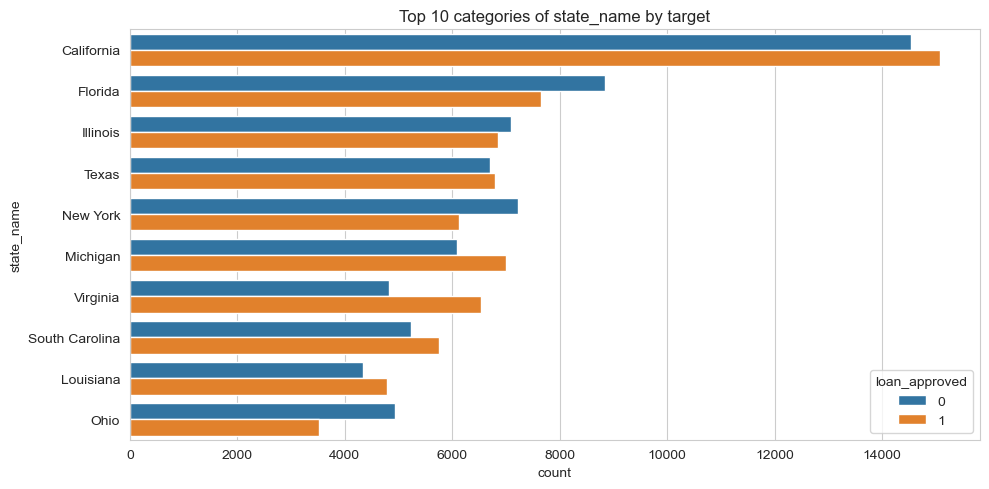

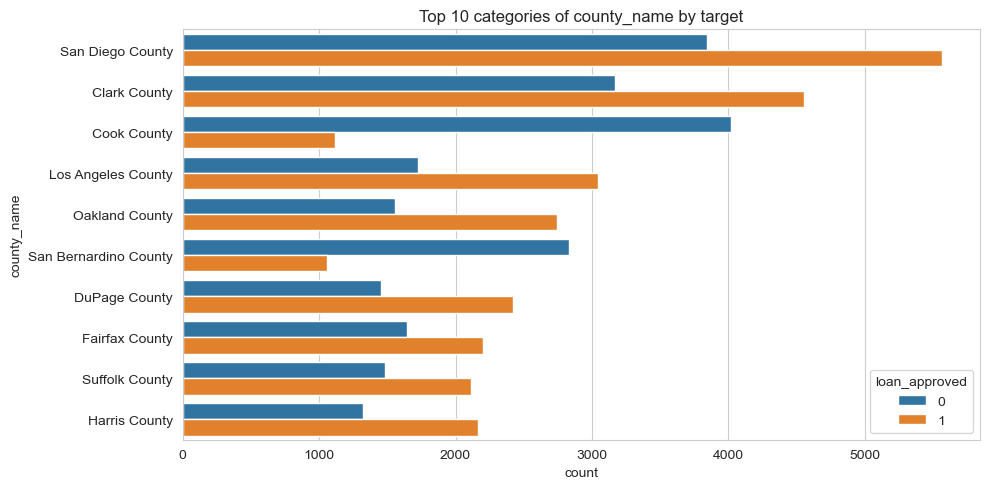

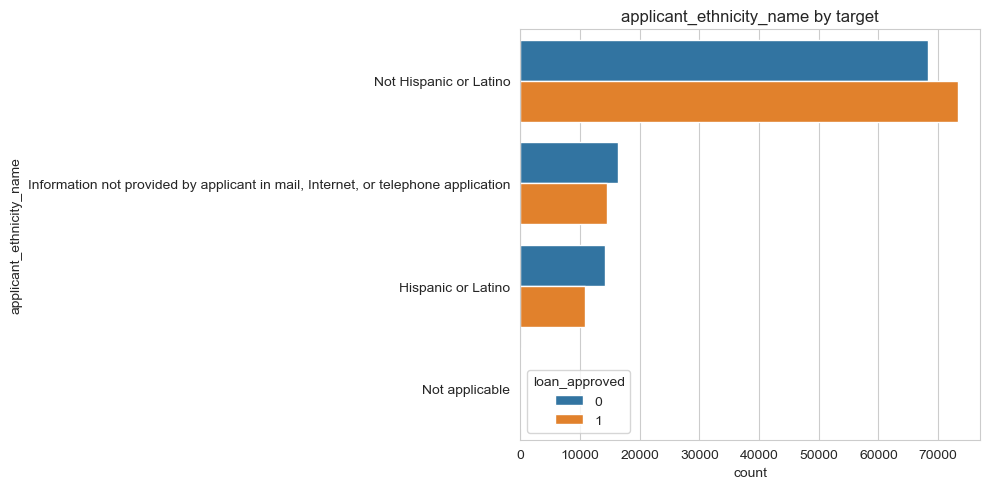

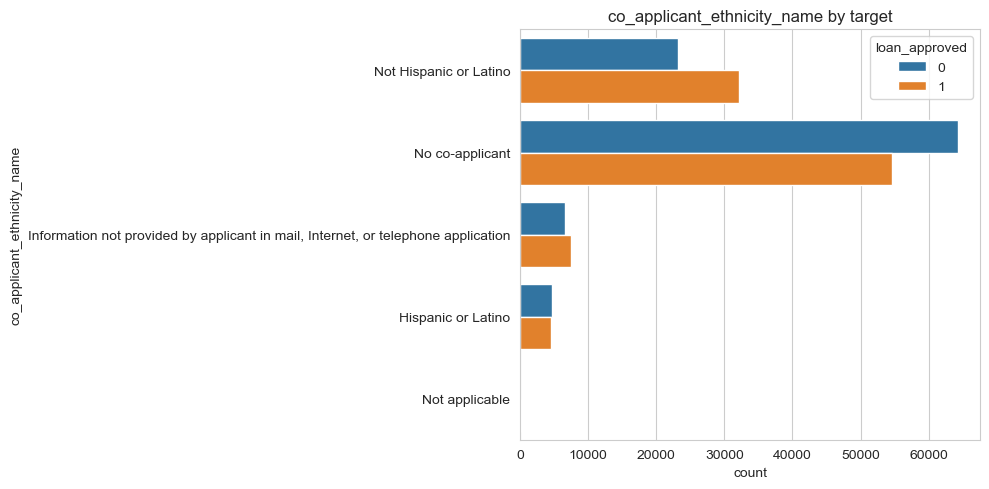

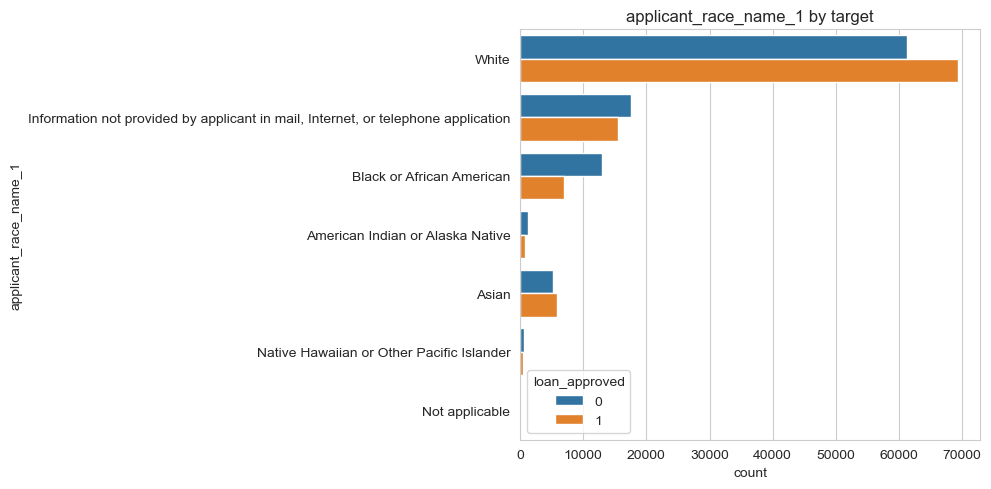

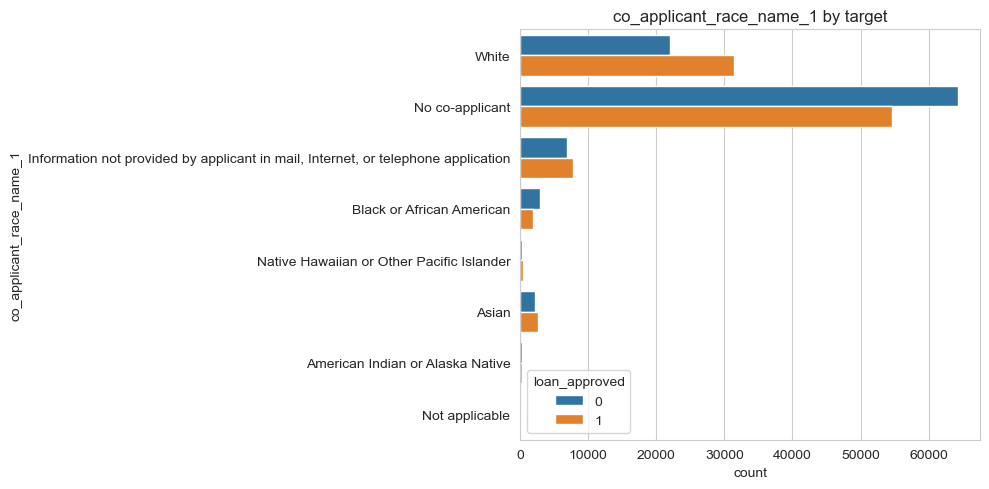

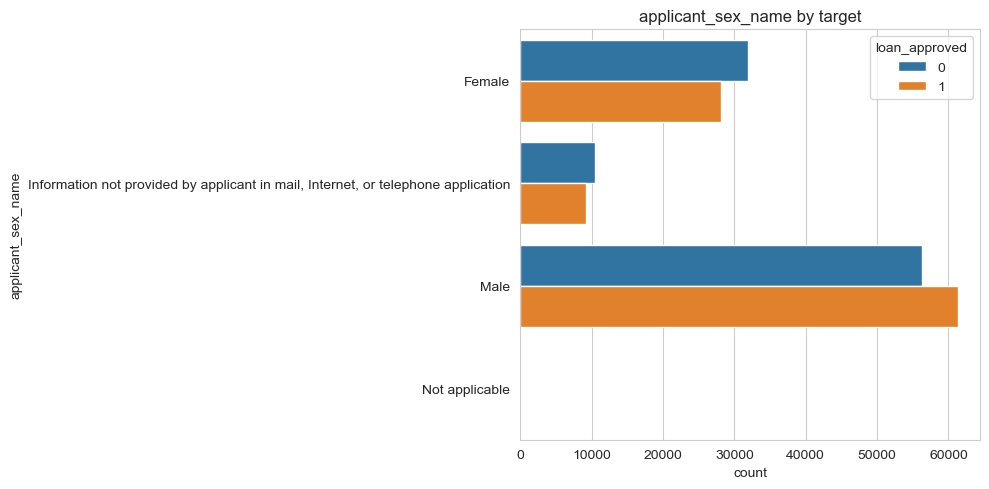

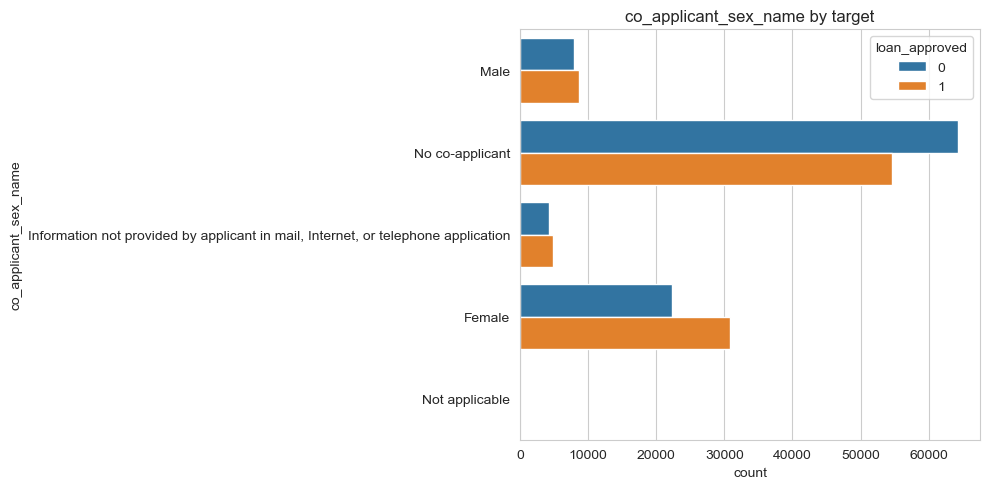

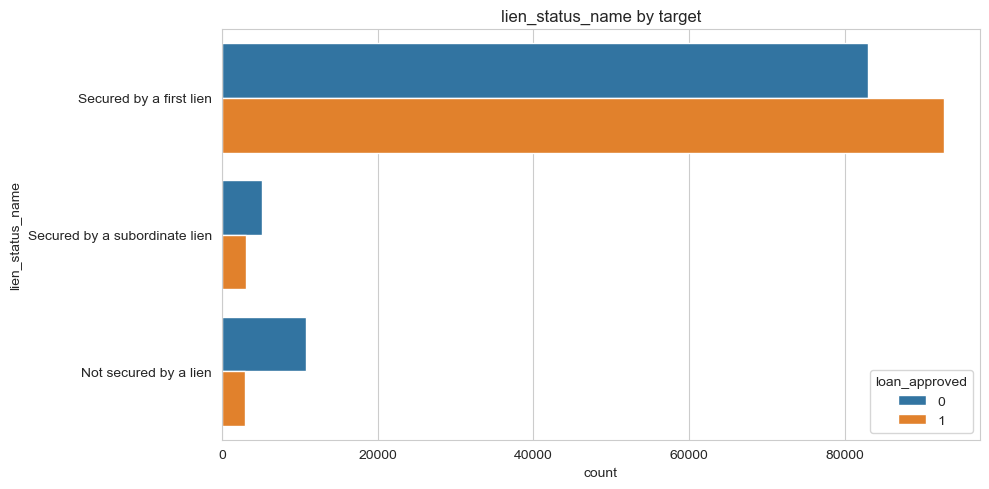

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df=under_sampled_df
feature_cols = [col for col in df.columns if col != TARGET_COL]
numeric_cols = df[feature_cols].select_dtypes(include='number').columns.tolist()
categorical_cols = [col for col in feature_cols if col not in numeric_cols]

def plot_numeric_feature(data, feature):
    plt.figure(figsize=(8, 4))
    sns.histplot(
        data=data,
        x=feature,
        hue=TARGET_COL,
        bins=40,
        stat='density',
        common_norm=False,
        kde=True,
        element='step',
    )
    plt.title(f'{feature} by target')
    plt.tight_layout()
    plt.show()

def plot_categorical_feature(data, feature, top_n=10):
    top_values = data[feature].astype(str).value_counts().head(top_n).index
    subset = data[data[feature].astype(str).isin(top_values)].copy()
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=subset,
        y=feature,
        hue=TARGET_COL,
        order=top_values,
    )
    plt.title(f'Top {top_n} categories of {feature} by target')
    plt.tight_layout()
    plt.show()

for feature in numeric_cols:
    plot_numeric_feature(df, feature)

for feature in categorical_cols:
    if df[feature].nunique(dropna=False) > 20:
        plot_categorical_feature(df, feature, top_n=10)
    else:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, y=feature, hue=TARGET_COL)
        plt.title(f'{feature} by target')
        plt.tight_layout()
        plt.show()


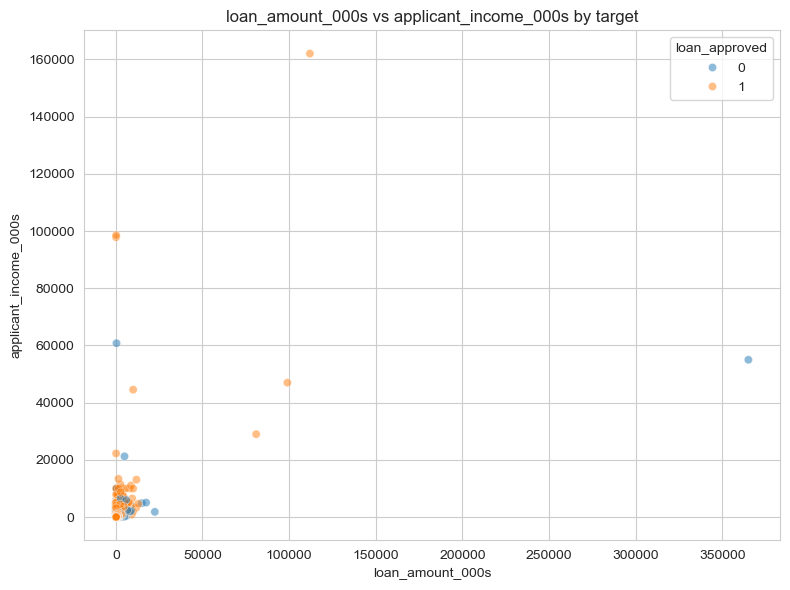

In [8]:
feature_x = 'loan_amount_000s'
feature_y = 'applicant_income_000s'

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x=feature_x,
    y=feature_y,
    hue=TARGET_COL,
    alpha=0.5,
    s=35,
)
plt.title(f'{feature_x} vs {feature_y} by target')
plt.tight_layout()
plt.show()


## 8) Pairplot برای چند ویژگی

در این بخش چند ویژگی عددی را با هم به‌صورت ماتریس پراکندگی نمایش می‌دهیم.
چون کل دیتاست بزرگ است، فقط یک نمونه‌ی کوچک از داده را برای رسم انتخاب می‌کنیم تا نمودار سریع‌تر و خواناتر باشد.

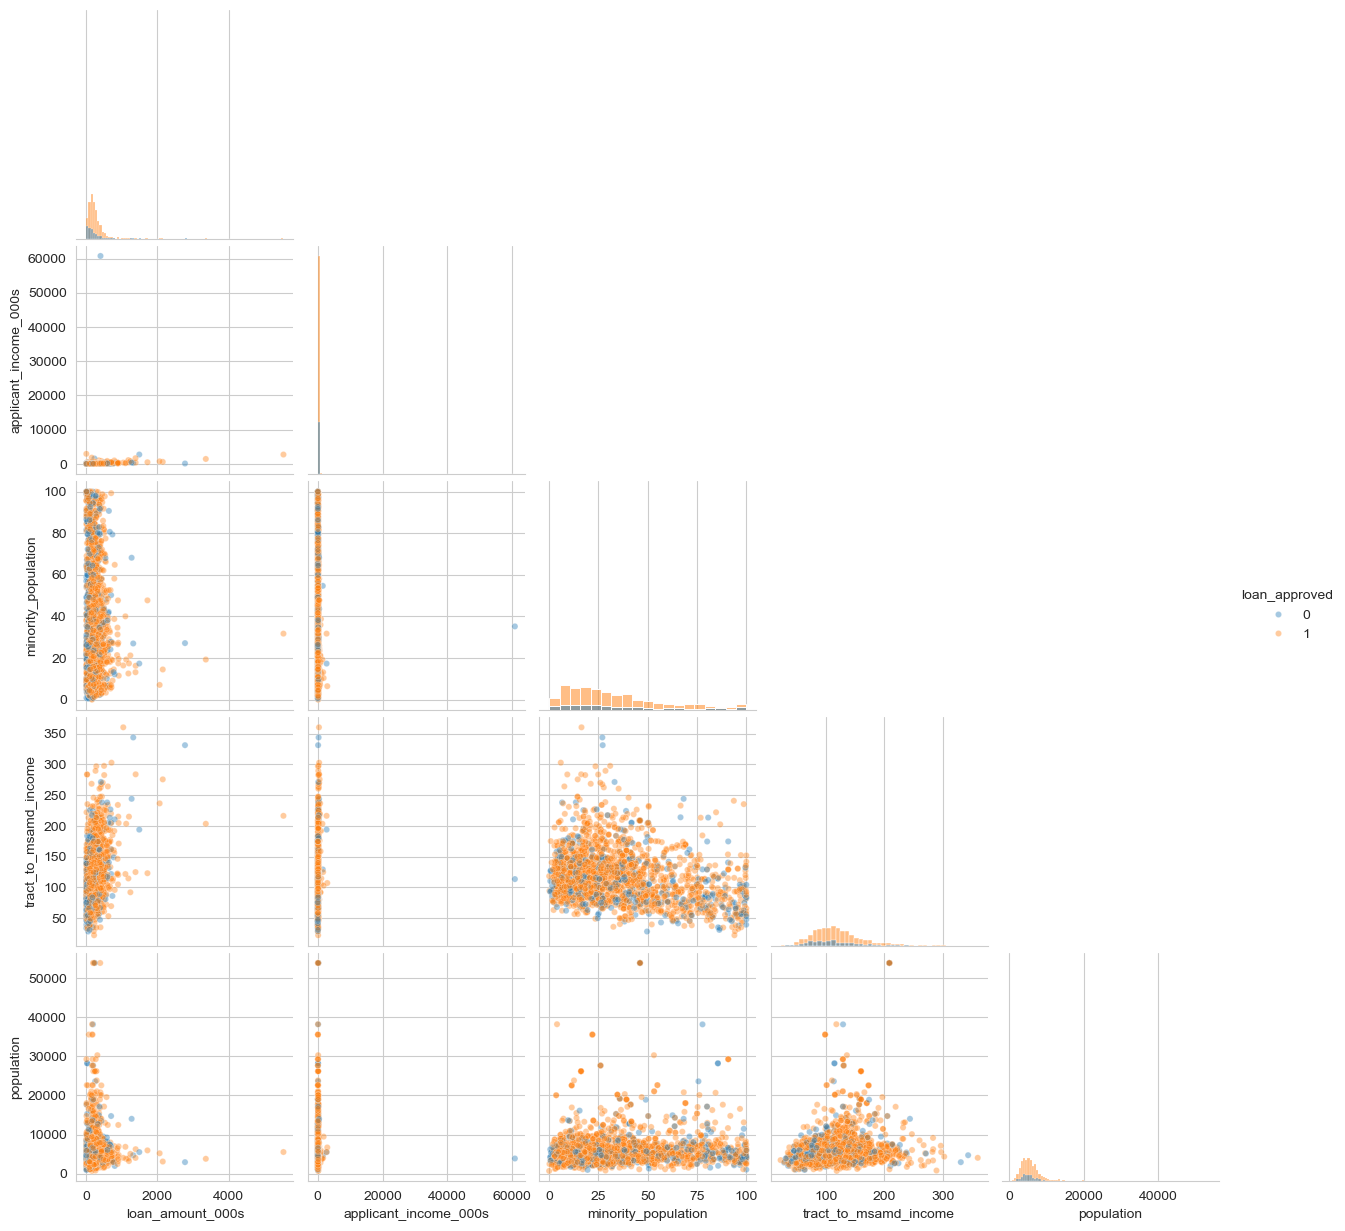

In [66]:
pair_features = [
    'loan_amount_000s',
    'applicant_income_000s',
    'minority_population',
    'tract_to_msamd_income',
    'population',
]

pair_df = df[pair_features + [TARGET_COL]].dropna()
sample_size = min(2000, len(pair_df))
pair_df = pair_df.sample(n=sample_size, random_state=RANDOM_STATE)

sns.pairplot(
    pair_df,
    vars=pair_features,
    hue=TARGET_COL,
    corner=True,
    diag_kind='hist',
    plot_kws={'alpha': 0.4, 's': 20},
)
plt.show()


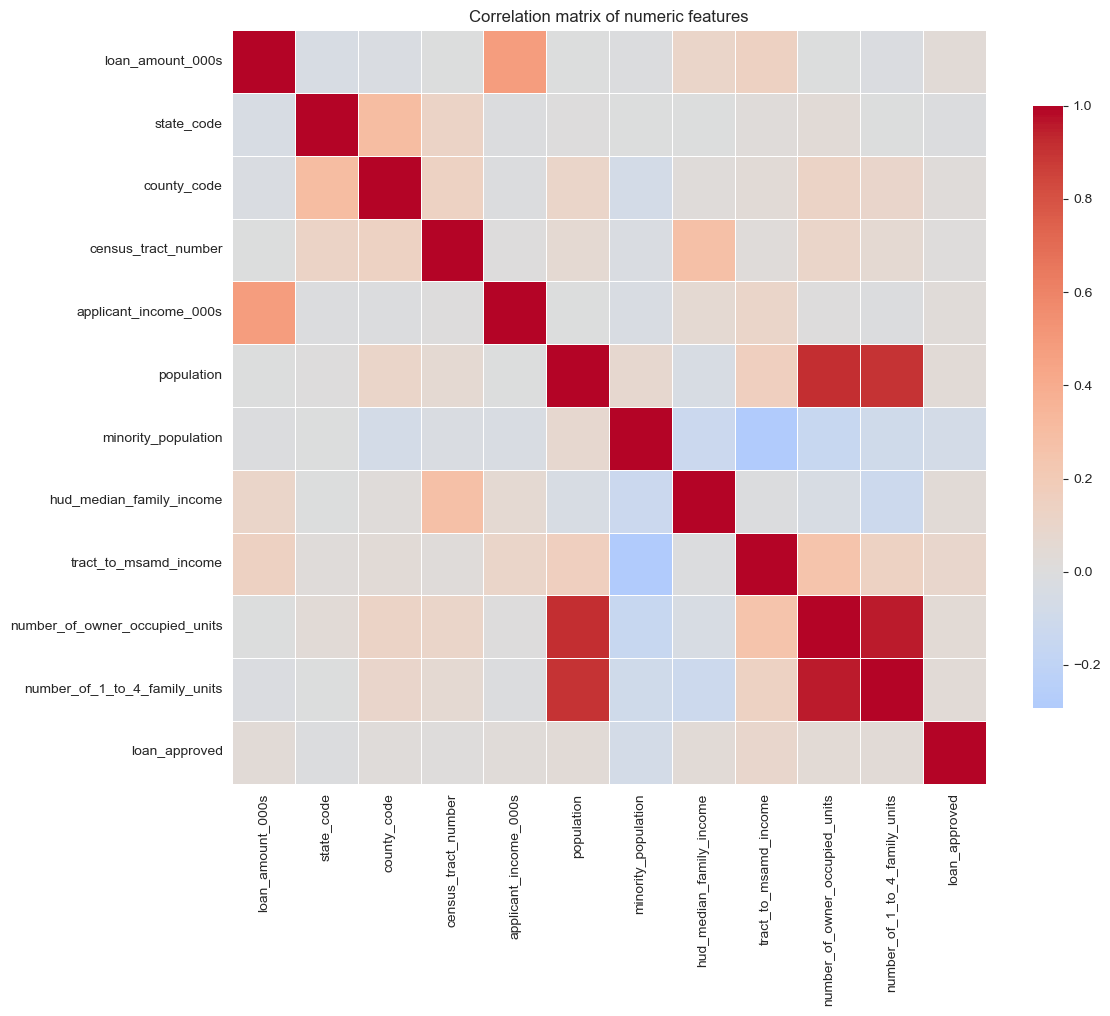

In [9]:
numeric_df = df.select_dtypes(include='number').copy()
corr_matrix = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
)
plt.title('Correlation matrix of numeric features')
plt.tight_layout()
plt.show()


## 10) آماده‌سازی داده برای مدل‌سازی و ساخت ویژگی‌های جدید

در این بخش یک مجموعه‌ی تست ثابت از داده‌ی اصلی جدا می‌کنیم، بعد روی داده‌ی مدل چند feature ترکیبی و لگاریتمی می‌سازیم تا مدل‌ها بتوانند نسبت‌های مهم مالی و منطقه‌ای را هم یاد بگیرند. سپس فقط داده‌ی آموزش را به دو روش متوازن می‌سازیم تا ارزیابی مدل‌ها واقعی‌تر باشد.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import joblib

DROP_COLS = ['respondent_id']
CODELIKE_CAT_COLS = ['state_code', 'county_code', 'census_tract_number']

ENGINEERED_NUMERIC_COLS = [
    'loan_to_income',
    'loan_to_median_income',
    'income_to_median_income',
    'owner_occupied_share',
    'owner_units_per_pop',
    'family_units_per_pop',
    'loan_per_population',
    'loan_per_family_unit',
    'log_loan_amount',
    'log_applicant_income',
    'log_population',
    'log_minority_population',
    'log_owner_occupied_units',
    'log_family_units',
    'log_hud_median_family_income',
    'log_tract_to_msamd_income',
    'has_co_applicant',
]


def add_engineered_features(data):
    model_df = data.copy()
    model_df['loan_to_income'] = model_df['loan_amount_000s'] / model_df['applicant_income_000s'].replace(0, np.nan)
    model_df['loan_to_median_income'] = model_df['loan_amount_000s'] / model_df['hud_median_family_income'].replace(0, np.nan)
    model_df['income_to_median_income'] = model_df['applicant_income_000s'] / model_df['hud_median_family_income'].replace(0, np.nan)
    model_df['owner_occupied_share'] = model_df['number_of_owner_occupied_units'] / model_df['number_of_1_to_4_family_units'].replace(0, np.nan)
    model_df['owner_units_per_pop'] = model_df['number_of_owner_occupied_units'] / model_df['population'].replace(0, np.nan)
    model_df['family_units_per_pop'] = model_df['number_of_1_to_4_family_units'] / model_df['population'].replace(0, np.nan)
    model_df['loan_per_population'] = model_df['loan_amount_000s'] / model_df['population'].replace(0, np.nan)
    model_df['loan_per_family_unit'] = model_df['loan_amount_000s'] / model_df['number_of_1_to_4_family_units'].replace(0, np.nan)
    model_df['log_loan_amount'] = np.log1p(model_df['loan_amount_000s'])
    model_df['log_applicant_income'] = np.log1p(model_df['applicant_income_000s'])
    model_df['log_population'] = np.log1p(model_df['population'])
    model_df['log_minority_population'] = np.log1p(model_df['minority_population'])
    model_df['log_owner_occupied_units'] = np.log1p(model_df['number_of_owner_occupied_units'])
    model_df['log_family_units'] = np.log1p(model_df['number_of_1_to_4_family_units'])
    model_df['log_hud_median_family_income'] = np.log1p(model_df['hud_median_family_income'])
    model_df['log_tract_to_msamd_income'] = np.log1p(model_df['tract_to_msamd_income'])
    model_df['has_co_applicant'] = (model_df['co_applicant_sex_name'] != 'No co-applicant').astype(int)
    return model_df


df_model = add_engineered_features(df)

train_base_df, test_base_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_model[TARGET_COL],
)

feature_cols = [col for col in df_model.columns if col not in [TARGET_COL, *DROP_COLS]]
categorical_cols = df_model[feature_cols].select_dtypes(include='object').columns.tolist()
for col in CODELIKE_CAT_COLS:
    if col in feature_cols and col not in categorical_cols:
        categorical_cols.append(col)

numeric_cols = [col for col in feature_cols if col not in categorical_cols]


def prepare_X(data):
    X = data.copy()
    if not set(ENGINEERED_NUMERIC_COLS).issubset(X.columns):
        X = add_engineered_features(X)
    X = X[feature_cols].copy()
    for col in categorical_cols:
        X[col] = X[col].astype('string').fillna('Missing')
    return X


def make_under_sampled_train(data):
    counts = data[TARGET_COL].value_counts()
    minority_label = counts.idxmin()
    majority_label = counts.idxmax()
    target_size = int(counts.min())

    minority_part = data[data[TARGET_COL] == minority_label]
    majority_part = data[data[TARGET_COL] == majority_label].sample(
        n=target_size,
        random_state=RANDOM_STATE,
        replace=False,
    )

    return (
        pd.concat([minority_part, majority_part], axis=0)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )


def make_200k_each_train(data, target_size=200_000):
    counts = data[TARGET_COL].value_counts()
    minority_label = counts.idxmin()
    majority_label = counts.idxmax()

    minority_part = data[data[TARGET_COL] == minority_label].sample(
        n=target_size,
        random_state=RANDOM_STATE,
        replace=True,
    )
    majority_part = data[data[TARGET_COL] == majority_label].sample(
        n=target_size,
        random_state=RANDOM_STATE,
        replace=False,
    )

    return (
        pd.concat([minority_part, majority_part], axis=0)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

under_sampled_train_df = make_under_sampled_train(train_base_df)
balanced_200k_train_df = make_200k_each_train(train_base_df)
unbalanced_train_df = train_base_df.copy()

train_datasets = {
    'under_sampled_train_df': under_sampled_train_df,
    'balanced_200k_train_df': balanced_200k_train_df,
    'unbalanced_train_df': unbalanced_train_df,
}

X_test_raw = prepare_X(test_base_df)
y_test = test_base_df[TARGET_COL].astype(int)

print('Train datasets:')
for dataset_name, dataset in train_datasets.items():
    print(dataset_name)
    print(dataset[TARGET_COL].value_counts().sort_index())

print('\nTest set:')
print(y_test.value_counts().sort_index())

print('\nEngineered feature columns:')
print(ENGINEERED_NUMERIC_COLS)

Train datasets:
under_sampled_train_df
loan_approved
0    79019
1    79019
Name: count, dtype: int64
balanced_200k_train_df
loan_approved
0    200000
1    200000
Name: count, dtype: int64
unbalanced_train_df
loan_approved
0     79019
1    320981
Name: count, dtype: int64

Test set:
loan_approved
0    19755
1    80245
Name: count, dtype: int64

Engineered feature columns:
['loan_to_income', 'loan_to_median_income', 'income_to_median_income', 'owner_occupied_share', 'owner_units_per_pop', 'family_units_per_pop', 'loan_per_population', 'loan_per_family_unit', 'log_loan_amount', 'log_applicant_income', 'log_population', 'log_minority_population', 'log_owner_occupied_units', 'log_family_units', 'log_hud_median_family_income', 'log_tract_to_msamd_income', 'has_co_applicant']


## 11) تابع ارزیابی مدل‌ها

در این سلول یک تابع مشترک برای محاسبه‌ی معیارهای ارزیابی می‌سازیم تا نتیجه‌ی همه‌ی مدل‌ها با یک قالب واحد گزارش شود.

In [11]:
ARTIFACT_DIR = Path('artifacts')
MODEL_DIR = ARTIFACT_DIR / 'models'
ARTIFACT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

RESULTS_CSV = ARTIFACT_DIR / 'model_results.csv'
RF_DEPTH_CSV = ARTIFACT_DIR / 'rf_depth_results.csv'


def load_existing_results():
    if RESULTS_CSV.exists():
        loaded_df = pd.read_csv(RESULTS_CSV)
        return loaded_df.to_dict('records')
    return []


All_model_results = load_existing_results()


def save_results():
    results_df = pd.DataFrame(All_model_results)
    if not results_df.empty:
        results_df.to_csv(RESULTS_CSV, index=False)


def upsert_result(result):
    global All_model_results
    All_model_results = [
        item for item in All_model_results
        if not (item['model'] == result['model'] and item['train_dataset'] == result['train_dataset'])
    ]
    All_model_results.append(result)
    save_results()
    return result


def add_model_result(model_name, dataset_name, y_true, y_pred, y_prob):
    result = {
        'model': model_name,
        'train_dataset': dataset_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    return upsert_result(result)


def show_results(model_name):
    results = pd.DataFrame(
        [result for result in All_model_results if result['model'] == model_name]
    )
    if results.empty:
        return results
    return results.sort_values('roc_auc', ascending=False)


def save_rf_depth_results(rf_depth_results):
    pd.DataFrame(rf_depth_results).to_csv(RF_DEPTH_CSV, index=False)


def load_model_artifact(filename):
    path = MODEL_DIR / filename
    if path.exists():
        return joblib.load(path)
    return None


def save_model_artifact(filename, obj):
    path = MODEL_DIR / filename
    joblib.dump(obj, path)
    return path

## 12) انکد کردن ویژگی‌ها برای مدل‌های scikit-learn

مدل‌هایی مثل Logistic Regression و Random Forest با متن خام کار نمی‌کنند. بنابراین ویژگی‌های دسته‌ای را با One-Hot Encoding تبدیل می‌کنیم و مقدارهای خالی عددی را با میانه پر می‌کنیم.

In [12]:
def build_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown='infrequent_if_exist',
            min_frequency=50,
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown='ignore',
            sparse=True,
        )


def build_preprocessor(scale_numeric=False):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler(with_mean=False)))

    return ColumnTransformer(
        transformers=[
            ('numeric', Pipeline(numeric_steps), numeric_cols),
            ('categorical', build_one_hot_encoder(), categorical_cols),
        ],
        remainder='drop',
    )

## 13) مدل Logistic Regression

این مدل یک baseline سریع و قابل تفسیر است. مدل روی هر دو دیتاست متوازن آموزش داده می‌شود و روی test set اصلی ارزیابی می‌شود.

In [13]:
from sklearn.linear_model import LogisticRegression

logistic_models = {}

logistic_train_datasets = {
    'under_sampled_train_df': under_sampled_train_df,
    'balanced_200k_train_df': balanced_200k_train_df,
    'unbalanced_train_df': unbalanced_train_df,
}

for dataset_name, dataset in logistic_train_datasets.items():
    is_weighted_unbalanced = dataset_name == 'unbalanced_train_df'
    model_filename = (
        f'logreg_weighted_{dataset_name}.joblib' if is_weighted_unbalanced
        else f'logreg_{dataset_name}.joblib'
    )
    model_path = MODEL_DIR / model_filename

    if model_path.exists():
        logistic_pipeline = joblib.load(model_path)
        print(f'Loaded existing model: {model_path.name}')
    else:
        X_train = prepare_X(dataset)
        y_train = dataset[TARGET_COL].astype(int)

        class_weight = 'balanced' if is_weighted_unbalanced else None

        logistic_pipeline = Pipeline(
            steps=[
                ('preprocess', build_preprocessor(scale_numeric=True)),
                ('model', LogisticRegression(
                    max_iter=5000,
                    solver='saga',
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                    class_weight=class_weight,
                )),
            ]
        )

        logistic_pipeline.fit(X_train, y_train)
        joblib.dump(logistic_pipeline, model_path)
        print(f'Saved model: {model_path.name}')

    y_pred = logistic_pipeline.predict(X_test_raw)
    y_prob = logistic_pipeline.predict_proba(X_test_raw)[:, 1]

    logistic_models[dataset_name] = logistic_pipeline
    add_model_result('Logistic Regression', dataset_name, y_test, y_pred, y_prob)

show_results('Logistic Regression')


Loaded existing model: logreg_under_sampled_train_df.joblib
Loaded existing model: logreg_balanced_200k_train_df.joblib
Loaded existing model: logreg_weighted_unbalanced_train_df.joblib


,model,train_dataset,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,confusion_matrix
1,Logistic Regression,balanced_200k_train_df,0.72985,0.718513,0.908883,0.737255,0.814122,0.788524,"[[13824, 5931], [21084, 59161]]"
2,Logistic Regression,unbalanced_train_df,0.72779,0.718050,0.909136,0.734152,0.812327,0.788067,"[[13867, 5888], [21333, 58912]]"
0,Logistic Regression,under_sampled_train_df,0.72659,0.716711,0.908576,0.733043,0.811424,0.787617,"[[13836, 5919], [21422, 58823]]"


## 14) جست‌وجوی بهترین Random Forest

در این بخش فقط `max_depth` را مرحله‌به‌مرحله بررسی می‌کنیم تا ببینیم کدام عمق درخت روی validation نتیجه‌ی بهتری می‌دهد.
بعد از انتخاب بهترین عمق، همان مقدار برای آموزش نهایی روی هر دو دیتاست متوازن استفاده می‌شود.


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_depth_grid = [4, 6, 8, 10, 12, 14, 16, 18, 20]
existing_rf_depth_df = pd.read_csv(RF_DEPTH_CSV) if RF_DEPTH_CSV.exists() else pd.DataFrame()
rf_depth_results = existing_rf_depth_df.to_dict('records') if not existing_rf_depth_df.empty else []
best_rf_depth_by_dataset = {}
random_forest_models = {}

for dataset_name, dataset in train_datasets.items():
    rf_cache_name = f'{dataset_name}_weighted' if dataset_name == 'unbalanced_train_df' else dataset_name
    dataset_depth_results_df = pd.DataFrame([r for r in rf_depth_results if r['train_dataset'] == rf_cache_name])

    if not dataset_depth_results_df.empty:
        dataset_depth_results_df = dataset_depth_results_df.sort_values(
            ['val_roc_auc', 'val_balanced_accuracy', 'val_f1'],
            ascending=False,
        )
        best_depth = int(dataset_depth_results_df.iloc[0]['max_depth'])
        best_rf_depth_by_dataset[rf_cache_name] = best_depth
        print(f'{rf_cache_name}: loaded best max_depth = {best_depth}')
        print(dataset_depth_results_df)
        continue

    rf_train_df, rf_val_df = train_test_split(
        dataset,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=dataset[TARGET_COL],
    )

    X_rf_train_raw = prepare_X(rf_train_df)
    y_rf_train = rf_train_df[TARGET_COL].astype(int)
    X_rf_val_raw = prepare_X(rf_val_df)
    y_rf_val = rf_val_df[TARGET_COL].astype(int)

    rf_preprocessor = build_preprocessor(scale_numeric=False)
    X_rf_train = rf_preprocessor.fit_transform(X_rf_train_raw)
    X_rf_val = rf_preprocessor.transform(X_rf_val_raw)

    dataset_depth_results = []
    rf_class_weight = 'balanced' if dataset_name == 'unbalanced_train_df' else None

    for depth in rf_depth_grid:
        rf_candidate = RandomForestClassifier(
            n_estimators=150,
            max_depth=depth,
            min_samples_leaf=20,
            class_weight=rf_class_weight,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
        rf_candidate.fit(X_rf_train, y_rf_train)
        val_pred = rf_candidate.predict(X_rf_val)
        val_prob = rf_candidate.predict_proba(X_rf_val)[:, 1]

        depth_result = {
            'train_dataset': rf_cache_name,
            'max_depth': depth,
            'val_accuracy': accuracy_score(y_rf_val, val_pred),
            'val_balanced_accuracy': balanced_accuracy_score(y_rf_val, val_pred),
            'val_precision': precision_score(y_rf_val, val_pred, zero_division=0),
            'val_recall': recall_score(y_rf_val, val_pred, zero_division=0),
            'val_f1': f1_score(y_rf_val, val_pred, zero_division=0),
            'val_roc_auc': roc_auc_score(y_rf_val, val_prob),
        }
        rf_depth_results.append(depth_result)
        dataset_depth_results.append(depth_result)
        save_rf_depth_results(rf_depth_results)

    dataset_depth_results_df = pd.DataFrame(dataset_depth_results).sort_values(
        ['val_roc_auc', 'val_balanced_accuracy', 'val_f1'],
        ascending=False,
    )
    best_depth = int(dataset_depth_results_df.iloc[0]['max_depth'])
    best_rf_depth_by_dataset[rf_cache_name] = best_depth
    print(f'{rf_cache_name}: best max_depth = {best_depth}')
    print(dataset_depth_results_df)

rf_depth_results_df = pd.DataFrame(rf_depth_results).sort_values(
    ['train_dataset', 'val_roc_auc', 'val_balanced_accuracy', 'val_f1'],
    ascending=[True, False, False, False],
)
print(rf_depth_results_df)

for dataset_name, dataset in train_datasets.items():
    rf_cache_name = f'{dataset_name}_weighted' if dataset_name == 'unbalanced_train_df' else dataset_name
    model_path = MODEL_DIR / f'rf_{rf_cache_name}.joblib'
    best_depth = best_rf_depth_by_dataset[rf_cache_name]
    rf_class_weight = 'balanced' if dataset_name == 'unbalanced_train_df' else None

    if model_path.exists():
        saved_rf = joblib.load(model_path)
        rf_preprocessor = saved_rf['preprocessor']
        random_forest_model = saved_rf['model']
        best_depth = saved_rf['best_max_depth']
        print(f'Loaded existing model: {model_path.name}')
    else:
        X_train = prepare_X(dataset)
        y_train = dataset[TARGET_COL].astype(int)

        rf_preprocessor = build_preprocessor(scale_numeric=False)
        X_train_processed = rf_preprocessor.fit_transform(X_train)

        random_forest_model = RandomForestClassifier(
            n_estimators=250,
            max_depth=best_depth,
            min_samples_leaf=20,
            class_weight=rf_class_weight,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

        random_forest_model.fit(X_train_processed, y_train)
        save_model_artifact(f'rf_{rf_cache_name}.joblib', {
            'preprocessor': rf_preprocessor,
            'model': random_forest_model,
            'best_max_depth': best_depth,
        })
        print(f'Saved model: rf_{rf_cache_name}.joblib')

    X_test_processed = rf_preprocessor.transform(X_test_raw)
    y_pred = random_forest_model.predict(X_test_processed)
    y_prob = random_forest_model.predict_proba(X_test_processed)[:, 1]

    random_forest_models[dataset_name] = {
        'preprocessor': rf_preprocessor,
        'model': random_forest_model,
        'best_max_depth': best_depth,
    }
    add_model_result('Random Forest', dataset_name, y_test, y_pred, y_prob)

show_results('Random Forest')


under_sampled_train_df: loaded best max_depth = 20
            train_dataset  max_depth  val_accuracy  val_balanced_accuracy  \
8  under_sampled_train_df         20      0.698747               0.698747   
7  under_sampled_train_df         18      0.695583               0.695583   
6  under_sampled_train_df         16      0.693843               0.693843   
5  under_sampled_train_df         14      0.691882               0.691882   
4  under_sampled_train_df         12      0.689382               0.689382   
3  under_sampled_train_df         10      0.684226               0.684226   
2  under_sampled_train_df          8      0.674576               0.674576   
1  under_sampled_train_df          6      0.668185               0.668185   
0  under_sampled_train_df          4      0.658915               0.658915   

   val_precision  val_recall    val_f1  val_roc_auc  
8       0.692558    0.714819  0.703512     0.768919  
7       0.685378    0.723108  0.703738     0.766573  
6       0.684737

,model,train_dataset,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,confusion_matrix
0,Random Forest,under_sampled_train_df,0.71188,0.703043,0.903440,0.717652,0.799900,0.771531,"[[13600, 6155], [22657, 57588]]"
1,Random Forest,balanced_200k_train_df,0.72542,0.702837,0.899883,0.740171,0.812250,0.771025,"[[13147, 6608], [20850, 59395]]"
2,Random Forest,unbalanced_train_df,0.72387,0.702596,0.900109,0.737766,0.810892,0.770264,"[[13185, 6570], [21043, 59202]]"


## 15) مدل CatBoost

CatBoost برای داده‌هایی که ویژگی دسته‌ای زیاد دارند معمولاً انتخاب قدرتمندی است، چون می‌تواند categorical featureها را مستقیم و بدون One-Hot Encoding مدیریت کند.

In [15]:
from catboost import CatBoostClassifier, Pool
import numpy as np

catboost_models = {}
cat_feature_indices = [feature_cols.index(col) for col in categorical_cols]

balanced_test_df = make_under_sampled_train(test_base_df)
X_test_cat = prepare_X(balanced_test_df)
y_test_cat = balanced_test_df[TARGET_COL].astype(int)

print('Balanced CatBoost test set:')
print(y_test_cat.value_counts().sort_index())

for dataset_name, dataset in train_datasets.items():
    cat_cache_name = f'{dataset_name}_weighted' if dataset_name == 'unbalanced_train_df' else dataset_name
    model_path = MODEL_DIR / f'catboost_{cat_cache_name}.cbm'

    if model_path.exists():
        cat_model = CatBoostClassifier()
        cat_model.load_model(str(model_path))
        print(f'Loaded existing model: {model_path.name}')
    else:
        X_train = prepare_X(dataset)
        y_train = dataset[TARGET_COL].astype(int)
        neg = int((y_train == 0).sum())
        pos = int((y_train == 1).sum())
        class_weights = [1.0, float(neg / max(pos, 1))] if dataset_name == 'unbalanced_train_df' else None

        train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
        test_pool = Pool(X_test_cat, y_test_cat, cat_features=cat_feature_indices)

        cat_model = CatBoostClassifier(
            loss_function='Logloss',
            eval_metric='AUC',
            iterations=1200,
            learning_rate=0.05,
            depth=10,
            class_weights=class_weights,
            random_seed=RANDOM_STATE,
            verbose=100,
            od_type='Iter',
            od_wait=50,
        )

        cat_model.fit(train_pool, eval_set=test_pool, use_best_model=True)
        cat_model.save_model(str(model_path))
        print(f'Saved model: {model_path.name}')

    y_pred = cat_model.predict(X_test_cat).astype(int).ravel()
    y_prob = cat_model.predict_proba(X_test_cat)[:, 1]

    catboost_models[dataset_name] = cat_model
    add_model_result('CatBoost', dataset_name, y_test_cat, y_pred, y_prob)

# Majority vote across the three CatBoost models
cat_pred_matrix = np.vstack([
    catboost_models[name].predict(X_test_cat).astype(int).ravel()
    for name in ['under_sampled_train_df', 'balanced_200k_train_df', 'unbalanced_train_df']
])
cat_prob_matrix = np.vstack([
    catboost_models[name].predict_proba(X_test_cat)[:, 1]
    for name in ['under_sampled_train_df', 'balanced_200k_train_df', 'unbalanced_train_df']
])
cat_majority_pred = (cat_pred_matrix.sum(axis=0) >= 2).astype(int)
cat_majority_prob = cat_prob_matrix.mean(axis=0)
add_model_result('CatBoost Majority Vote', 'catboost_ensemble', y_test_cat, cat_majority_pred, cat_majority_prob)
print()
print('CatBoost majority vote result:')
print(show_results('CatBoost Majority Vote').to_string(index=False))

show_results('CatBoost')


Balanced CatBoost test set:
loan_approved
0    19755
1    19755
Name: count, dtype: int64
Loaded existing model: catboost_under_sampled_train_df.cbm
Loaded existing model: catboost_balanced_200k_train_df.cbm
Loaded existing model: catboost_unbalanced_train_df_weighted.cbm

CatBoost majority vote result:
                 model     train_dataset  accuracy  balanced_accuracy  precision   recall       f1  roc_auc               confusion_matrix
CatBoost Majority Vote catboost_ensemble  0.743002           0.743002   0.724459 0.784308 0.753196 0.823644 [[13862, 5893], [4261, 15494]]


,model,train_dataset,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,confusion_matrix
2,CatBoost,unbalanced_train_df,0.743888,0.743888,0.719639,0.799089,0.757286,0.825275,"[[13605, 6150], [3969, 15786]]"
0,CatBoost,under_sampled_train_df,0.741686,0.741686,0.728368,0.770843,0.749004,0.822240,"[[14076, 5679], [4527, 15228]]"
1,CatBoost,balanced_200k_train_df,0.729132,0.729132,0.714414,0.763452,0.738120,0.801677,"[[13726, 6029], [4673, 15082]]"


## 16) مدل LightGBM

LightGBM برای دیتاست‌های بزرگ سریع و معمولاً دقیق است. در این بخش ویژگی‌های دسته‌ای را به نوع category تبدیل می‌کنیم تا مدل بتواند آن‌ها را بهتر پردازش کند.

In [16]:
from lightgbm import LGBMClassifier

lightgbm_models = {}


def prepare_lgbm_X(data):
    X = prepare_X(data)
    for col in categorical_cols:
        X[col] = X[col].astype('category')
    return X

balanced_test_df = make_under_sampled_train(test_base_df)
X_test_lgbm = prepare_lgbm_X(balanced_test_df)
y_test_lgbm = balanced_test_df[TARGET_COL].astype(int)

print('Balanced LightGBM test set:')
print(y_test_lgbm.value_counts().sort_index())

for dataset_name, dataset in train_datasets.items():
    lgbm_cache_name = f'{dataset_name}_weighted' if dataset_name == 'unbalanced_train_df' else dataset_name
    model_path = MODEL_DIR / f'lgbm_{lgbm_cache_name}.joblib'

    if model_path.exists():
        lgbm_model = joblib.load(model_path)
        print(f'Loaded existing model: {model_path.name}')
    else:
        X_train = prepare_lgbm_X(dataset)
        y_train = dataset[TARGET_COL].astype(int)
        lgbm_class_weight = 'balanced' if dataset_name == 'unbalanced_train_df' else None

        lgbm_model = LGBMClassifier(
            objective='binary',
            n_estimators=700,
            learning_rate=0.04,
            num_leaves=64,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight=lgbm_class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

        lgbm_model.fit(
            X_train,
            y_train,
            categorical_feature=categorical_cols,
        )
        save_model_artifact(f'lgbm_{lgbm_cache_name}.joblib', lgbm_model)
        print(f'Saved model: {model_path.name}')

    y_pred = lgbm_model.predict(X_test_lgbm)
    y_prob = lgbm_model.predict_proba(X_test_lgbm)[:, 1]

    lightgbm_models[dataset_name] = lgbm_model
    add_model_result('LightGBM', dataset_name, y_test_lgbm, y_pred, y_prob)

show_results('LightGBM')


Balanced LightGBM test set:
loan_approved
0    19755
1    19755
Name: count, dtype: int64
Loaded existing model: lgbm_under_sampled_train_df.joblib
Loaded existing model: lgbm_balanced_200k_train_df.joblib
Loaded existing model: lgbm_unbalanced_train_df_weighted.joblib


,model,train_dataset,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,confusion_matrix
2,LightGBM,unbalanced_train_df,0.728448,0.728448,0.699938,0.799747,0.746521,0.805362,"[[12982, 6773], [3956, 15799]]"
0,LightGBM,under_sampled_train_df,0.726221,0.726221,0.718854,0.743052,0.730753,0.803393,"[[14014, 5741], [5076, 14679]]"
1,LightGBM,balanced_200k_train_df,0.723513,0.723513,0.691570,0.806884,0.744790,0.798548,"[[12646, 7109], [3815, 15940]]"


## 17) مقایسه‌ی نهایی مدل‌ها

در این بخش نتیجه‌ی همه‌ی مدل‌ها کنار هم نمایش داده می‌شود تا مشخص شود کدام مدل و کدام روش sampling عملکرد بهتری داشته است.

In [17]:
# Majority vote across Logistic Regression, Random Forest, CatBoost, and LightGBM
import numpy as np
import joblib
from catboost import CatBoostClassifier

balanced_vote_test_df = make_under_sampled_train(test_base_df)
X_vote_raw = prepare_X(balanced_vote_test_df)
X_vote_lgbm = prepare_lgbm_X(balanced_vote_test_df)
y_vote = balanced_vote_test_df[TARGET_COL].astype(int)

def _load_logistic_model(dataset_name):
    model_path = MODEL_DIR / (f'logreg_weighted_{dataset_name}.joblib' if dataset_name == 'unbalanced_train_df' else f'logreg_{dataset_name}.joblib')
    return logistic_models.get(dataset_name) or joblib.load(model_path)

def _load_rf_bundle(dataset_name):
    cache_name = f'{dataset_name}_weighted' if dataset_name == 'unbalanced_train_df' else dataset_name
    model_path = MODEL_DIR / f'rf_{cache_name}.joblib'
    return random_forest_models.get(dataset_name) or joblib.load(model_path)

def _load_cat_model(dataset_name):
    cache_name = f'{dataset_name}_weighted' if dataset_name == 'unbalanced_train_df' else dataset_name
    model = catboost_models.get(dataset_name)
    if model is not None:
        return model
    model = CatBoostClassifier()
    model.load_model(str(MODEL_DIR / f'catboost_{cache_name}.cbm'))
    return model

def _load_lgbm_model(dataset_name):
    cache_name = f'{dataset_name}_weighted' if dataset_name == 'unbalanced_train_df' else dataset_name
    model_path = MODEL_DIR / f'lgbm_{cache_name}.joblib'
    return lightgbm_models.get(dataset_name) or joblib.load(model_path)

logistic_preds, logistic_probs = [], []
rf_preds, rf_probs = [], []
cat_preds, cat_probs = [], []
lgbm_preds, lgbm_probs = [], []

for dataset_name in ['under_sampled_train_df', 'balanced_200k_train_df', 'unbalanced_train_df']:
    logistic_model = _load_logistic_model(dataset_name)
    rf_bundle = _load_rf_bundle(dataset_name)
    cat_model = _load_cat_model(dataset_name)
    lgbm_model = _load_lgbm_model(dataset_name)

    logistic_pred = logistic_model.predict(X_vote_raw).astype(int)
    logistic_prob = logistic_model.predict_proba(X_vote_raw)[:, 1]
    logistic_preds.append(logistic_pred)
    logistic_probs.append(logistic_prob)

    rf_processed = rf_bundle['preprocessor'].transform(X_vote_raw)
    rf_pred = rf_bundle['model'].predict(rf_processed).astype(int)
    rf_prob = rf_bundle['model'].predict_proba(rf_processed)[:, 1]
    rf_preds.append(rf_pred)
    rf_probs.append(rf_prob)

    cat_pred = cat_model.predict(X_vote_raw).astype(int).ravel()
    cat_prob = cat_model.predict_proba(X_vote_raw)[:, 1]
    cat_preds.append(cat_pred)
    cat_probs.append(cat_prob)

    lgbm_pred = lgbm_model.predict(X_vote_lgbm).astype(int)
    lgbm_prob = lgbm_model.predict_proba(X_vote_lgbm)[:, 1]
    lgbm_preds.append(lgbm_pred)
    lgbm_probs.append(lgbm_prob)

all_pred_matrix = np.vstack(logistic_preds + rf_preds + cat_preds + lgbm_preds)
all_prob_matrix = np.vstack(logistic_probs + rf_probs + cat_probs + lgbm_probs)
majority_threshold = all_pred_matrix.shape[0] // 2 + 1
majority_pred = (all_pred_matrix.sum(axis=0) >= majority_threshold).astype(int)
majority_prob = all_prob_matrix.mean(axis=0)

ensemble_result = add_model_result('All Models Majority Vote', 'balanced_vote_test', y_vote, majority_pred, majority_prob)
print('All-model majority vote result:')
print(pd.DataFrame([ensemble_result]).to_string(index=False))
ensemble_result


All-model majority vote result:
                   model      train_dataset  accuracy  balanced_accuracy  precision   recall       f1  roc_auc               confusion_matrix
All Models Majority Vote balanced_vote_test  0.735561           0.735561   0.726878 0.754695 0.740526 0.815781 [[14153, 5602], [4846, 14909]]


{'model': 'All Models Majority Vote',
 'train_dataset': 'balanced_vote_test',
 'accuracy': 0.7355606175651733,
 'balanced_accuracy': 0.7355606175651733,
 'precision': 0.7268782604456145,
 'recall': 0.7546950139205264,
 'f1': 0.7405255053891621,
 'roc_auc': 0.8157806311317692,
 'confusion_matrix': [[14153, 5602], [4846, 14909]]}

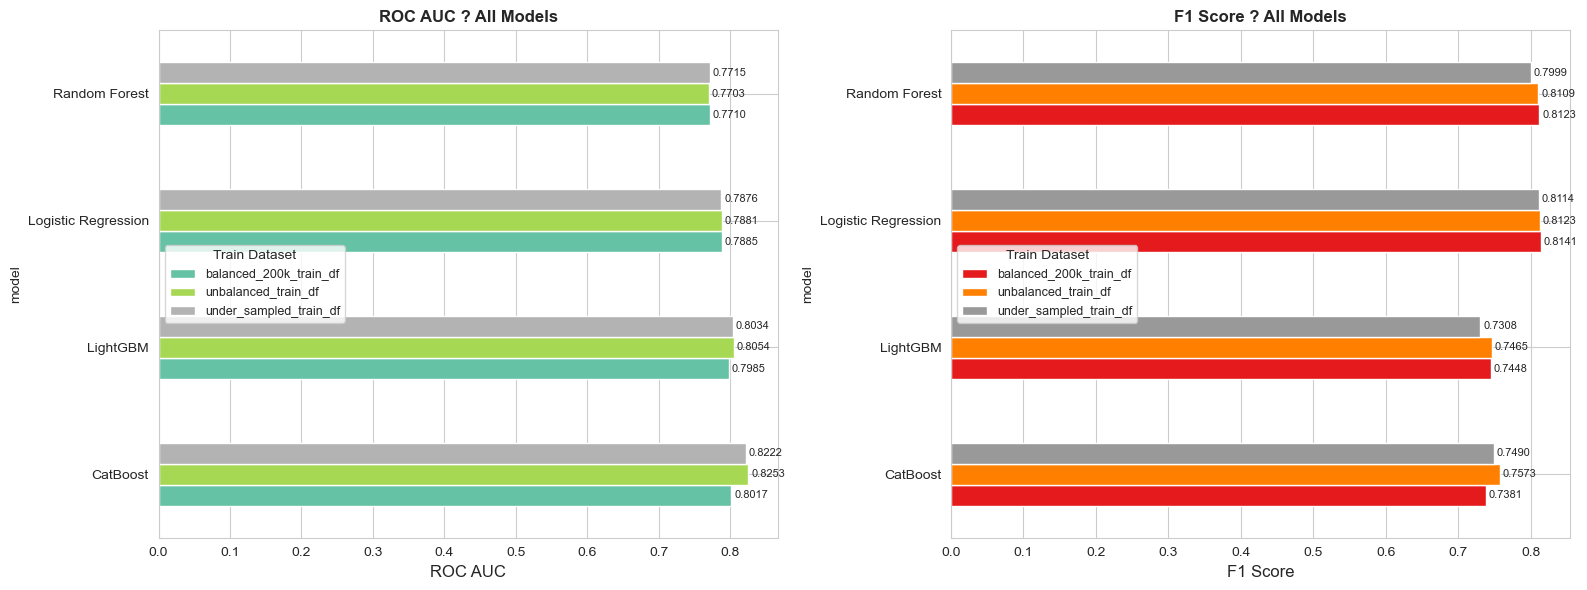

,model,train_dataset,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,confusion_matrix
8,CatBoost,unbalanced_train_df,0.743888,0.743888,0.719639,0.799089,0.757286,0.825275,"[[13605, 6150], [3969, 15786]]"
9,CatBoost Majority Vote,catboost_ensemble,0.743002,0.743002,0.724459,0.784308,0.753196,0.823644,"[[13862, 5893], [4261, 15494]]"
6,CatBoost,under_sampled_train_df,0.741686,0.741686,0.728368,0.770843,0.749004,0.822240,"[[14076, 5679], [4527, 15228]]"
13,All Models Majority Vote,balanced_vote_test,0.735561,0.735561,0.726878,0.754695,0.740526,0.815781,"[[14153, 5602], [4846, 14909]]"
12,LightGBM,unbalanced_train_df,0.728448,0.728448,0.699938,0.799747,0.746521,0.805362,"[[12982, 6773], [3956, 15799]]"
10,LightGBM,under_sampled_train_df,0.726221,0.726221,0.718854,0.743052,0.730753,0.803393,"[[14014, 5741], [5076, 14679]]"
7,CatBoost,balanced_200k_train_df,0.729132,0.729132,0.714414,0.763452,0.738120,0.801677,"[[13726, 6029], [4673, 15082]]"
11,LightGBM,balanced_200k_train_df,0.723513,0.723513,0.691570,0.806884,0.744790,0.798548,"[[12646, 7109], [3815, 15940]]"
1,Logistic Regression,balanced_200k_train_df,0.729850,0.718513,0.908883,0.737255,0.814122,0.788524,"[[13824, 5931], [21084, 59161]]"
2,Logistic Regression,unbalanced_train_df,0.727790,0.718050,0.909136,0.734152,0.812327,0.788067,"[[13867, 5888], [21333, 58912]]"


In [26]:
results_df = pd.DataFrame(All_model_results)
results_df = results_df.sort_values(['roc_auc', 'f1', 'balanced_accuracy'], ascending=False)
results_df.to_csv(ARTIFACT_DIR / 'final_sorted_results.csv', index=False)
results_df

models_to_compare = ['Logistic Regression', 'Random Forest',
                     'CatBoost', 'LightGBM']

compare_df = pd.DataFrame([
    r for r in All_model_results
    if r['model'] in models_to_compare
]).sort_values('roc_auc', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_auc = compare_df.pivot(index='model', columns='train_dataset', values='roc_auc')
pivot_auc.plot(kind='barh', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_xlabel('ROC AUC', fontsize=12)
axes[0].set_title('ROC AUC ? All Models', fontweight='bold')
axes[0].legend(title='Train Dataset', fontsize=9)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f', fontsize=8, padding=2)

pivot_f1 = compare_df.pivot(index='model', columns='train_dataset', values='f1')
pivot_f1.plot(kind='barh', ax=axes[1], colormap='Set1', edgecolor='white')
axes[1].set_xlabel('F1 Score', fontsize=12)
axes[1].set_title('F1 Score ? All Models', fontweight='bold')
axes[1].legend(title='Train Dataset', fontsize=9)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'adaboost_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

results_df

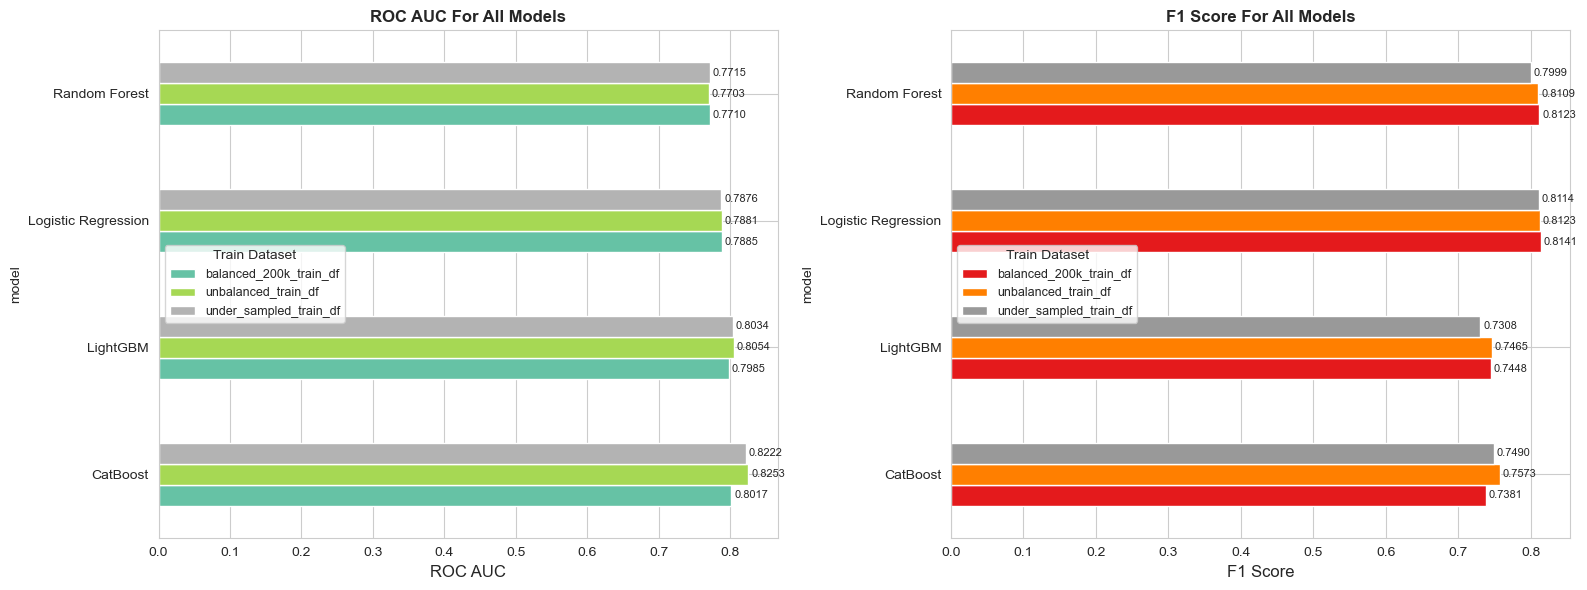

,model,train_dataset,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,confusion_matrix
8,CatBoost,unbalanced_train_df,0.743888,0.743888,0.719639,0.799089,0.757286,0.825275,"[[13605, 6150], [3969, 15786]]"
9,CatBoost Majority Vote,catboost_ensemble,0.743002,0.743002,0.724459,0.784308,0.753196,0.823644,"[[13862, 5893], [4261, 15494]]"
6,CatBoost,under_sampled_train_df,0.741686,0.741686,0.728368,0.770843,0.749004,0.822240,"[[14076, 5679], [4527, 15228]]"
13,All Models Majority Vote,balanced_vote_test,0.735561,0.735561,0.726878,0.754695,0.740526,0.815781,"[[14153, 5602], [4846, 14909]]"
12,LightGBM,unbalanced_train_df,0.728448,0.728448,0.699938,0.799747,0.746521,0.805362,"[[12982, 6773], [3956, 15799]]"
10,LightGBM,under_sampled_train_df,0.726221,0.726221,0.718854,0.743052,0.730753,0.803393,"[[14014, 5741], [5076, 14679]]"
7,CatBoost,balanced_200k_train_df,0.729132,0.729132,0.714414,0.763452,0.738120,0.801677,"[[13726, 6029], [4673, 15082]]"
11,LightGBM,balanced_200k_train_df,0.723513,0.723513,0.691570,0.806884,0.744790,0.798548,"[[12646, 7109], [3815, 15940]]"
1,Logistic Regression,balanced_200k_train_df,0.729850,0.718513,0.908883,0.737255,0.814122,0.788524,"[[13824, 5931], [21084, 59161]]"
2,Logistic Regression,unbalanced_train_df,0.727790,0.718050,0.909136,0.734152,0.812327,0.788067,"[[13867, 5888], [21333, 58912]]"


In [27]:

models_to_compare = ['Logistic Regression', 'Random Forest',
                     'CatBoost', 'LightGBM']

compare_df = pd.DataFrame([
    r for r in All_model_results
    if r['model'] in models_to_compare
]).sort_values('roc_auc', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_auc = compare_df.pivot(index='model', columns='train_dataset', values='roc_auc')
pivot_auc.plot(kind='barh', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_xlabel('ROC AUC', fontsize=12)
axes[0].set_title('ROC AUC For All Models', fontweight='bold')
axes[0].legend(title='Train Dataset', fontsize=9)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f', fontsize=8, padding=2)

pivot_f1 = compare_df.pivot(index='model', columns='train_dataset', values='f1')
pivot_f1.plot(kind='barh', ax=axes[1], colormap='Set1', edgecolor='white')
axes[1].set_xlabel('F1 Score', fontsize=12)
axes[1].set_title('F1 Score For All Models', fontweight='bold')
axes[1].legend(title='Train Dataset', fontsize=9)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'adaboost_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
results_df